# gubapost 覆盖方向消融实验

用 gubapost_v1 **自身**的 attention output coverage directions 做 4 套消融:
对 12 层 attention output 同时施加 through-origin 投影, 在 256 条评估文本上测量
CLS 表征距离 + 冻结头(class_1 prob/logit)变化。

**4 套方案**(方向来自 gubapost_v1 的 C_64 / C_640):

| # | K | 方向集 | 干预 | 保留维度 |
|---|---|---|---|---|
| 1 | 64 | 低覆盖 451 维 (γ<0.05) | keep | 451 |
| 2 | 64 | 低覆盖 451 维 | drop (=keep 补 317) | 317 |
| 3 | 640 | 高覆盖 318 维 (γ≥0.90) | drop (=keep 补 450) | 450 |
| 4 | 640 | 高覆盖 318 维 | keep | 318 |

额外 baseline: `original`(无干预) + `zero_all`(全清零) = 共 6 condition。

**产物**: `gubapost_v1/extensions/coverage_ablation_v1/`(parquet + npz, <5MB)
**GPU**: cuda:1, fp16, max_length=512
**耗时**: <1 min

In [2]:
# 1. 计算 coverage 方向(纯线性代数, 秒级, 无 GPU)
import os, sys
import numpy as np

ROOT = "/home/intern_fjq_2026/Projects/chinese-wwm-roberta"
os.chdir(ROOT)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.activation_subspace_coverage import load_layer_bases, compute_projector, coverage_spectrum
from src.activation_rank import load_activation_rank_config, _model_paths, _run_directory

config = load_activation_rank_config(os.path.join(ROOT, "configs", "activation_rank_guba.yaml"))
RUN_DIR = _run_directory(config)
base, checkpoint = _model_paths(config)
print("run dir:", RUN_DIR)

sub = np.load(RUN_DIR / "analysis" / "subspaces.npz", allow_pickle=False)
layers = list(range(1, 13))

# --- K=64: C_64 = mean(P_l), P_l = V_{l,64} V_{l,64}^T ---
bases_64 = load_layer_bases(sub, layers, 64)
proj_64 = [compute_projector(V) for V in bases_64]
eigvals_64, eigvecs_64 = coverage_spectrum(proj_64)  # descending

low_mask_64 = eigvals_64 < 0.05
Q_keep_low_451 = eigvecs_64[:, low_mask_64]     # [768, 451]
Q_keep_high_317 = eigvecs_64[:, ~low_mask_64]   # [768, 317]

# --- K=640 ---
bases_640 = load_layer_bases(sub, layers, 640)
proj_640 = [compute_projector(V) for V in bases_640]
eigvals_640, eigvecs_640 = coverage_spectrum(proj_640)

high_mask_640 = eigvals_640 >= 0.90
Q_keep_high_318 = eigvecs_640[:, high_mask_640]  # [768, 318]
Q_keep_low_450 = eigvecs_640[:, ~high_mask_640]  # [768, 450]

# --- 验证 ---
assert Q_keep_low_451.shape[1] == 451, f"K64 low<0.05: expected 451, got {Q_keep_low_451.shape[1]}"
assert Q_keep_high_317.shape[1] == 317
assert Q_keep_high_318.shape[1] == 318, f"K640 high>=0.90: expected 318, got {Q_keep_high_318.shape[1]}"
assert Q_keep_low_450.shape[1] == 450

for name, Q in [("keep_451_lowcov_K64", Q_keep_low_451),
                ("keep_317_complement_K64", Q_keep_high_317),
                ("keep_318_highcov_K640", Q_keep_high_318),
                ("keep_450_complement_K640", Q_keep_low_450)]:
    err = float(np.max(np.abs(Q.T @ Q - np.eye(Q.shape[1]))))
    print(f"  {name}: shape={Q.shape}, orthonormality_err={err:.2e}")
print("方向计算完成, 4 组方向全部通过正交性验证。")

run dir: /home/intern_fjq_2026/Projects/chinese-wwm-roberta/artifacts/checkpoint_activation_rank/runs/gubapost_v1
  keep_451_lowcov_K64: shape=(768, 451), orthonormality_err=3.11e-15
  keep_317_complement_K64: shape=(768, 317), orthonormality_err=2.00e-15
  keep_318_highcov_K640: shape=(768, 318), orthonormality_err=3.32e-15
  keep_450_complement_K640: shape=(768, 450), orthonormality_err=4.66e-15
方向计算完成, 4 组方向全部通过正交性验证。


In [3]:
# 2. 加载模型 + 选 256 评估文本 + baseline
import hashlib, pandas as pd, torch

from src.activation_rank_loss_recovery import (
    _load_candidate, _tokenize_evaluation, select_disjoint_evaluation_reports,
)

DEVICE = "cuda:1"
MAX_LENGTH = 512
N_EVAL = 256

candidate, tokenizer = _load_candidate(base=base, checkpoint=checkpoint,
                                        device=DEVICE, dtype_name="float16")
print("model loaded on", DEVICE)

# 评估文本: 从 gubapost 采样中选 256 条, 与 PCA sample 按 ID+text_hash 隔离
TEXT_SAMPLE = os.path.join(ROOT, "artifacts", "gubapost_baseline", "gubapost_text_sample.parquet")
reports = pd.read_parquet(TEXT_SAMPLE, columns=["post_id", "text"])
reports = reports.sample(n=min(20000, len(reports)), random_state=42)
reports = reports.rename(columns={"post_id": "report_id"})
reports["text_sha256"] = reports["text"].apply(
    lambda t: hashlib.sha256(str(t).encode("utf-8")).hexdigest()
)

sample_manifest = pd.read_parquet(RUN_DIR / "sample" / "sample_manifest.parquet")
if "post_id" in sample_manifest.columns and "report_id" not in sample_manifest.columns:
    sample_manifest = sample_manifest.rename(columns={"post_id": "report_id"})

selected = select_disjoint_evaluation_reports(
    reports, sample_manifest, report_count=N_EVAL, order_seed="coverage_ablation_v1"
)
print(f"评估文本: {len(selected)} 条 (与 PCA sample 零重叠)")

encoded = _tokenize_evaluation(tokenizer, selected, max_length=MAX_LENGTH)
encoded = {k: v.to(DEVICE) for k, v in encoded.items()}

# baseline (无干预)
with torch.inference_mode():
    out = candidate(**encoded)
baseline_cls = out.pooled_feature.float().cpu()        # [256, 768]
baseline_prob1 = out.probabilities[:, 1].float().cpu()  # [256]
baseline_logit1 = out.logits[:, 1].float().cpu()        # [256]
print(f"baseline CLS: {baseline_cls.shape}, prob1 range: [{baseline_prob1.min():.4f}, {baseline_prob1.max():.4f}]")

/home/intern_fjq_2026/miniconda3/envs/nlp_fjq/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


model loaded on cuda:1
评估文本: 256 条 (与 PCA sample 零重叠)
baseline CLS: torch.Size([256, 768]), prob1 range: [0.0999, 0.4556]


In [4]:
# 3. 运行 6 个 condition (全 12 层 attention output 同时投影)
from contextlib import ExitStack
from src.activation_rank_loss_recovery import resolve_projection_module, SingleSiteProjection

modules = [(l, resolve_projection_module(candidate.bert, f"attention_output_{l:02d}"))
           for l in range(1, 13)]
eye768 = np.eye(768, dtype=np.float32)

conditions = [
    ("original",                  None,                       0),
    ("zero_all",                  eye768,                     0),
    ("keep_451_lowcov_K64",       Q_keep_low_451.astype(np.float32),   451),
    ("drop_451_lowcov_K64",       Q_keep_high_317.astype(np.float32), 317),
    ("drop_318_highcov_K640",     Q_keep_low_450.astype(np.float32),  450),
    ("keep_318_highcov_K640",     Q_keep_high_318.astype(np.float32),  318),
]

results = []
for name, basis, n_comp in conditions:
    with ExitStack() as stack:
        if basis is not None:
            for l, module in modules:
                stack.enter_context(SingleSiteProjection(module, basis, n_comp))
        with torch.inference_mode():
            out = candidate(**encoded)
        mod_cls = out.pooled_feature.float().cpu()
        mod_prob1 = out.probabilities[:, 1].float().cpu()
        mod_logit1 = out.logits[:, 1].float().cpu()

    l2 = ((mod_cls - baseline_cls) ** 2).sum(dim=1)
    cos = torch.nn.functional.cosine_similarity(mod_cls, baseline_cls, dim=1)
    prob_mae = (mod_prob1 - baseline_prob1).abs()
    logit_mae = (mod_logit1 - baseline_logit1).abs()
    finite = torch.isfinite(mod_cls).all(dim=1) & torch.isfinite(mod_prob1)

    for i in range(len(selected)):
        results.append({
            "condition": name,
            "text_id": str(selected.iloc[i]["report_id"]),
            "cls_squared_l2_distance": float(l2[i]),
            "cls_cosine_similarity": float(cos[i]),
            "class_1_prob": float(mod_prob1[i]),
            "class_1_prob_mae": float(prob_mae[i]),
            "class_1_logit": float(mod_logit1[i]),
            "class_1_logit_mae": float(logit_mae[i]),
            "finite": bool(finite[i]),
        })
    print(f"{name:30s}  mean_L2={l2.mean():.4f}  mean_cos={cos.mean():.6f}  "
          f"prob_mae={prob_mae.mean():.6f}  logit_mae={logit_mae.mean():.4f}  "
          f"finite={int(finite.sum())}/{len(finite)}")

print(f"\n共 {len(results)} 条 per-text 记录 (6 condition × {len(selected)} 文本)")

original                        mean_L2=0.0000  mean_cos=1.000000  prob_mae=0.000000  logit_mae=0.0000  finite=256/256
zero_all                        mean_L2=185.2247  mean_cos=0.775943  prob_mae=0.036394  logit_mae=0.1842  finite=256/256
keep_451_lowcov_K64             mean_L2=242.7527  mean_cos=0.709246  prob_mae=0.051883  logit_mae=0.3050  finite=256/256
drop_451_lowcov_K64             mean_L2=77.5017  mean_cos=0.906053  prob_mae=0.037351  logit_mae=0.2056  finite=256/256
drop_318_highcov_K640           mean_L2=184.3323  mean_cos=0.778068  prob_mae=0.040632  logit_mae=0.2290  finite=256/256
keep_318_highcov_K640           mean_L2=141.6124  mean_cos=0.830863  prob_mae=0.040182  logit_mae=0.1979  finite=256/256

共 1536 条 per-text 记录 (6 condition × 256 文本)


In [5]:
# 4. 保存产物 (parquet + npz + manifest, <5MB)
import json

OUT_DIR = RUN_DIR / "extensions" / "coverage_ablation_v1"
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.DataFrame(results)
df.to_parquet(OUT_DIR / "report_distances.parquet", index=False)

summary = df.groupby("condition").agg(
    n_texts=("text_id", "count"),
    mean_cls_l2=("cls_squared_l2_distance", "mean"),
    median_cls_l2=("cls_squared_l2_distance", "median"),
    mean_cls_cos=("cls_cosine_similarity", "mean"),
    mean_prob_mae=("class_1_prob_mae", "mean"),
    mean_logit_mae=("class_1_logit_mae", "mean"),
    n_finite=("finite", "sum"),
).reset_index()
summary.to_parquet(OUT_DIR / "condition_summary.parquet", index=False)

np.savez_compressed(OUT_DIR / "direction_sets.npz",
    keep_451_lowcov_K64=Q_keep_low_451.astype(np.float32),
    keep_317_complement_K64=Q_keep_high_317.astype(np.float32),
    keep_318_highcov_K640=Q_keep_high_318.astype(np.float32),
    keep_450_complement_K640=Q_keep_low_450.astype(np.float32),
    coverage_eigenvalues_K64=eigvals_64,
    coverage_eigenvalues_K640=eigvals_640,
)

manifest = {
    "schema": "coverage_ablation_v1",
    "source_run": str(RUN_DIR),
    "conditions": [c[0] for c in conditions],
    "direction_counts": {"K64_below_005": 451, "K640_above_090": 318},
    "n_eval_texts": len(selected),
    "max_length": MAX_LENGTH,
    "device": DEVICE,
    "dtype": "float16",
    "created_at": pd.Timestamp.now().isoformat(),
}
with open(OUT_DIR / "manifest.json", "w") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)

print("产物已保存:", OUT_DIR)
for f in sorted(OUT_DIR.iterdir()):
    print(f"  {f.name}: {f.stat().st_size:,} B")

产物已保存: /home/intern_fjq_2026/Projects/chinese-wwm-roberta/artifacts/checkpoint_activation_rank/runs/gubapost_v1/extensions/coverage_ablation_v1
  condition_summary.parquet: 5,504 B
  direction_sets.npz: 4,397,233 B
  manifest.json: 543 B
  report_distances.parquet: 49,476 B


=== Condition Summary ===
            condition  n_texts  mean_cls_l2  median_cls_l2  mean_cls_cos  mean_prob_mae  mean_logit_mae  n_finite
drop_318_highcov_K640      256   184.332250     186.883087      0.778069       0.040632        0.229050       256
  drop_451_lowcov_K64      256    77.501740      76.941872      0.906053       0.037351        0.205631       256
keep_318_highcov_K640      256   141.612356     146.188370      0.830863       0.040182        0.197935       256
  keep_451_lowcov_K64      256   242.752693     245.392479      0.709246       0.051883        0.304957       256
             original      256     0.000000       0.000000      1.000000       0.000000        0.000000       256
             zero_all      256   185.224705     191.401352      0.775943       0.036394        0.184215       256

=== Recovery vs zero_all ===
            condition  mean_cls_l2  mean_cls_cos  recovery_pct
drop_318_highcov_K640   184.332250      0.778069      0.481823
  drop_451_lowcov_K6

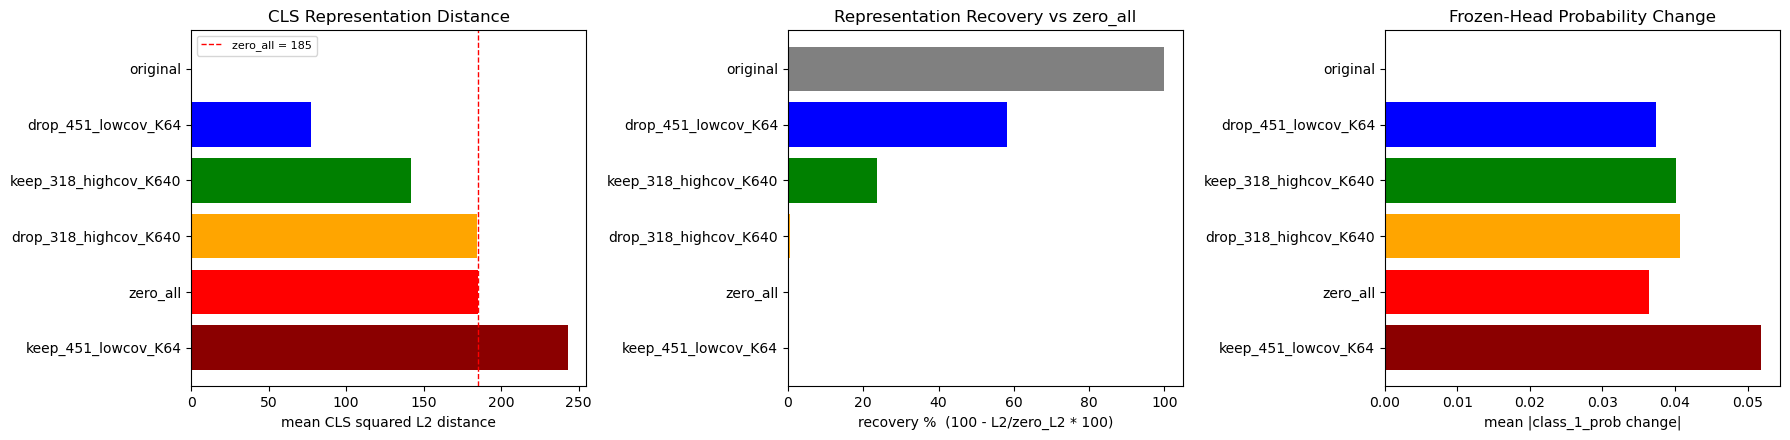

In [6]:
# 5. 结果展示
import matplotlib.pyplot as plt

print("=== Condition Summary ===")
print(summary.to_string(index=False))
print()

# recovery vs zero_all (公式修正: recovery = (1 - L2/zero_L2) * 100)
zero_l2 = float(summary.loc[summary.condition == "zero_all", "mean_cls_l2"].values[0])
summary["recovery_pct"] = ((1 - summary.mean_cls_l2 / zero_l2) * 100).clip(lower=0, upper=100) if zero_l2 > 0 else 0
print("=== Recovery vs zero_all ===")
print(summary[["condition", "mean_cls_l2", "mean_cls_cos", "recovery_pct"]].to_string(index=False))

# 按 L2 升序排列(最轻破坏在前)
s = summary.sort_values("mean_cls_l2")
colors = {"original": "gray", "zero_all": "red",
          "keep_451_lowcov_K64": "darkred", "drop_451_lowcov_K64": "blue",
          "drop_318_highcov_K640": "orange", "keep_318_highcov_K640": "green"}
bar_colors = [colors.get(c, "gray") for c in s.condition]

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# Panel 1: CLS L2 distance + zero_all 参考线
axes[0].barh(s.condition, s.mean_cls_l2, color=bar_colors)
axes[0].axvline(zero_l2, color="red", ls="--", lw=1, label=f"zero_all = {zero_l2:.0f}")
axes[0].set_xlabel("mean CLS squared L2 distance")
axes[0].set_title("CLS Representation Distance")
axes[0].invert_yaxis()
axes[0].legend(fontsize=8)

# Panel 2: Recovery % vs zero_all
axes[1].barh(s.condition, s.recovery_pct, color=bar_colors)
axes[1].axvline(0, color="black", ls="-", lw=0.5)
axes[1].set_xlabel("recovery %  (100 - L2/zero_L2 * 100)")
axes[1].set_title("Representation Recovery vs zero_all")
axes[1].invert_yaxis()

# Panel 3: 冻结头概率变化
axes[2].barh(s.condition, s.mean_prob_mae, color=bar_colors)
axes[2].set_xlabel("mean |class_1_prob change|")
axes[2].set_title("Frozen-Head Probability Change")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()